# SKILL-1 : Data loading and preprocessing dataset- the given project data using pytorch 


In [11]:
# Skill-1: Data loading and preprocessing using PyTorch
import pandas as pd
import torch
from torch.utils.data import Dataset

# Load the dataset
df = pd.read_csv("/kaggle/input/resume-job/resume_job_dataset.csv")

# 1. Build Vocabulary
def build_vocab(df, min_freq=2):
    vocab = {"<UNK>": 0}  # Unknown token
    word_counts = {}

    # Count word occurrences from both resume and job description
    for text in df['resume_text'].tolist() + df['job_description_text'].tolist():
        words = str(text).lower().split()
        for word in words:
            word_counts[word] = word_counts.get(word, 0) + 1

    index = 1
    for word, count in word_counts.items():
        if count >= min_freq:
            vocab[word] = index
            index += 1

    return vocab

# 2. Convert text to tensor
def text_to_tensor(text, vocab):
    tokens = str(text).lower().split()
    indices = [vocab.get(token, vocab["<UNK>"]) for token in tokens]
    return torch.tensor(indices, dtype=torch.long)

# 3. Define PyTorch Dataset
class ResumeDataset(Dataset):
    def __init__(self, df, vocab):
        self.df = df.reset_index(drop=True)
        self.vocab = vocab

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        resume_tensor = text_to_tensor(row['resume_text'], self.vocab)
        job_desc_tensor = text_to_tensor(row['job_description_text'], self.vocab)
        label = int(row['label'])
        return resume_tensor, job_desc_tensor, label

# 4. Encode labels
label_mapping = {
    "No Fit": 0,
    "Potential Fit": 1,
    "Good Fit": 2
}
df["label"] = df["label"].map(label_mapping)
df = df.dropna(subset=["label"])  # Drop rows with unmapped labels
df["label"] = df["label"].astype(int)

# 5. Build vocabulary from data
vocab = build_vocab(df, min_freq=2)

# 6. Initialize Dataset
dataset = ResumeDataset(df, vocab)

# 7. Print sample information
print("Label distribution:")
print(df["label"].value_counts())
print(f"\nTotal samples in dataset: {len(dataset)}")

# 8. Show a sample
sample_index = 5000 if len(dataset) > 5000 else 0
resume, job_desc, label = dataset[sample_index]
print("\nSample Data:")
print("Resume Tensor:", resume)
print("Job Description Tensor:", job_desc)
print("Label:", label)


Label distribution:
label
0    3143
1    1556
2    1542
Name: count, dtype: int64

Total samples in dataset: 6241

Sample Data:
Resume Tensor: tensor([   12, 53296,   656,  ..., 53429, 53430,    78])
Job Description Tensor: tensor([  480, 14399,  2364,   605,  4878,   352,  1605,     9,  6543,  1037,
          198,  1784,  5996, 61833,    41, 20749,   161,    32,    15,   698,
         5010,   842,    43,  5996,    90,  1887, 61885,    54,   800,    15,
          281,  3836,  1221,  8361,   531,    54, 61886,   131,   161,  1037,
          198,  1966, 14923,   688,  1827,  2149,    53,  1887,  7937,  4502,
         9469,     9, 11083,   698,  4033,   262,    53,    54, 31027,  2505,
          140,  1001,    53,    45,    15, 61887,  1391,  2109,  3836,  9058,
        14923, 11289,  1827,   161, 61888, 61889,     9,   161, 61258,  5996,
         5478,  1594,  1593,   794,   629,  6855,    15,    54,  4538,     9,
         5647,  1558,  1739,  3608,    53, 20318, 11587,     5,  1739,    

# SKILL-2 : Implement Sequential model to classify (binary /multiclass ) the given project data  using pytorch

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import pandas as pd

# --------------------- Step 1: Load Data ---------------------
df = pd.read_csv("/kaggle/input/resume-job/resume_job_dataset.csv")

# --------------------- Step 2: Preprocess Labels ---------------------
label_mapping = {
    "No Fit": 0,
    "Potential Fit": 1,
    "Good Fit": 2
}
df["label"] = df["label"].map(label_mapping)
df = df.dropna(subset=["label"])  # Remove rows where label is NaN
df["label"] = df["label"].astype(int)

# --------------------- Step 3: Build Vocabulary ---------------------
def build_vocab(df, min_freq=2):
    vocab = {"<UNK>": 0}
    word_counts = {}

    texts = df['resume_text'].tolist() + df['job_description_text'].tolist()
    for text in texts:
        words = str(text).lower().split()
        for word in words:
            word_counts[word] = word_counts.get(word, 0) + 1

    index = 1
    for word, count in word_counts.items():
        if count >= min_freq:
            vocab[word] = index
            index += 1

    return vocab

vocab = build_vocab(df)

# --------------------- Step 4: Text to Tensor ---------------------
def text_to_tensor(text, vocab, max_len=100):
    words = str(text).lower().split()
    indices = [vocab.get(word, vocab["<UNK>"]) for word in words]
    if len(indices) < max_len:
        indices += [0] * (max_len - len(indices))
    else:
        indices = indices[:max_len]
    return torch.tensor(indices)

# --------------------- Step 5: PyTorch Dataset ---------------------
class ResumeDataset(Dataset):
    def __init__(self, df, vocab):
        self.resumes = df["resume_text"].tolist()
        self.jobs = df["job_description_text"].tolist()
        self.labels = df["label"].tolist()
        self.vocab = vocab

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        resume_tensor = text_to_tensor(self.resumes[idx], self.vocab)
        job_tensor = text_to_tensor(self.jobs[idx], self.vocab)
        label = torch.tensor(self.labels[idx])
        return resume_tensor, job_tensor, label

dataset = ResumeDataset(df, vocab)

# --------------------- Step 6: Split Data ---------------------
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

# --------------------- Step 7: Define Model ---------------------
class ResumeClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim=300, hidden_dim=256, output_dim=3, dropout_rate=0.4):
        super(ResumeClassifier, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        self.resume_branch = nn.Sequential(
            nn.Linear(embedding_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU()
        )

        self.job_branch = nn.Sequential(
            nn.Linear(embedding_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU()
        )

        self.combined_layers = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.LeakyReLU(),
            nn.Dropout(dropout_rate / 2),
            nn.Linear(hidden_dim // 2, output_dim)
        )

    def forward(self, resume_x, job_x):
        resume_emb = self.embedding(resume_x).mean(dim=1)
        job_emb = self.embedding(job_x).mean(dim=1)

        resume_feat = self.resume_branch(resume_emb)
        job_feat = self.job_branch(job_emb)

        combined = torch.cat((resume_feat, job_feat), dim=1)
        return self.combined_layers(combined)

# --------------------- Step 8: Train the Model ---------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = ResumeClassifier(len(vocab)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 5
for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for resumes, jobs, labels in train_loader:
        resumes, jobs, labels = resumes.to(device), jobs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(resumes, jobs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {avg_loss:.4f}")

# --------------------- Step 9: Evaluate the Model ---------------------
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for resumes, jobs, labels in test_loader:
        resumes, jobs, labels = resumes.to(device), jobs.to(device), labels.to(device)
        outputs = model(resumes, jobs)
        predicted = torch.argmax(outputs, dim=1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

accuracy = correct / total
print(f"\n✅ Test Accuracy: {accuracy:.4f}")


Using device: cuda
Epoch 1/5 - Loss: 1.0396
Epoch 2/5 - Loss: 0.8881
Epoch 3/5 - Loss: 0.8165
Epoch 4/5 - Loss: 0.7642
Epoch 5/5 - Loss: 0.7417

✅ Test Accuracy: 0.6741


# SKILL-3 : Implement Sequential model to classify project  data by adding various optimization techniques ADAM, SGD, RMSPROP with pytorch and compare the result

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import pandas as pd
import numpy as np
from nltk.stem import WordNetLemmatizer
from torch.nn.utils.rnn import pad_sequence
from collections import Counter
import nltk
nltk.download('wordnet')

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load data
df = pd.read_csv("/kaggle/input/resume-job/resume_job_dataset.csv")
df = df.dropna(subset=["resume_text", "job_description_text", "label"])

# Label mapping
label_mapping = {'No Fit': 0, 'Potential Fit': 1, 'Good Fit': 2}
df['label'] = df['label'].map(label_mapping)

# Build vocabulary
def build_vocab(texts, min_freq=2):
    counter = Counter()
    for text in texts:
        words = str(text).lower().split()
        counter.update(words)
    vocab = {"<PAD>": 0, "<UNK>": 1}
    idx = 2
    for word, freq in counter.items():
        if freq >= min_freq:
            vocab[word] = idx
            idx += 1
    return vocab

vocab = build_vocab(df["resume_text"].tolist() + df["job_description_text"].tolist())

# Text to tensor
def text_to_tensor(text, vocab):
    words = str(text).lower().split()
    return torch.tensor([vocab.get(word, vocab["<UNK>"]) for word in words], dtype=torch.long)

# Custom Dataset
class ResumeDataset(Dataset):
    def __init__(self, dataframe, vocab):
        self.data = dataframe
        self.vocab = vocab

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        resume = text_to_tensor(self.data.iloc[idx]['resume_text'], self.vocab)
        job = text_to_tensor(self.data.iloc[idx]['job_description_text'], self.vocab)
        label = int(self.data.iloc[idx]['label'])
        return resume, job, label

# Collate function with padding
def collate_fn(batch):
    resumes, jobs, labels = zip(*batch)
    resumes_padded = pad_sequence(resumes, batch_first=True, padding_value=0)
    jobs_padded = pad_sequence(jobs, batch_first=True, padding_value=0)
    labels = torch.tensor(labels, dtype=torch.long)
    return resumes_padded, jobs_padded, labels

# Dataset and DataLoader
dataset = ResumeDataset(df, vocab)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=32, collate_fn=collate_fn)

# Define Model
class ResumeClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim=100, hidden_dim=64, output_dim=3):
        super(ResumeClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.model = nn.Sequential(
            nn.Linear(embedding_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, resume_x, job_x):
        resume_emb = self.embedding(resume_x).mean(dim=1)
        job_emb = self.embedding(job_x).mean(dim=1)
        combined = torch.cat((resume_emb, job_emb), dim=1)
        return self.model(combined)

# Training & Evaluation
def train_and_evaluate(optimizer_name):
    print(f"\n🚀 Training with {optimizer_name}")
    model = ResumeClassifier(vocab_size=len(vocab)).to(device)
    criterion = nn.CrossEntropyLoss()

    if optimizer_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=0.01)
    elif optimizer_name == "SGD":
        optimizer = optim.SGD(model.parameters(), lr=0.01)
    elif optimizer_name == "RMSprop":
        optimizer = optim.RMSprop(model.parameters(), lr=0.01)
    else:
        raise ValueError("Invalid optimizer")

    for epoch in range(5):
        model.train()
        total_loss = 0
        for resumes, jobs, labels in train_loader:
            resumes = resumes.to(device)
            jobs = jobs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(resumes, jobs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

    # Evaluation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for resumes, jobs, labels in test_loader:
            resumes = resumes.to(device)
            jobs = jobs.to(device)
            labels = labels.to(device)

            outputs = model(resumes, jobs)
            predicted = torch.argmax(outputs, dim=1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    accuracy = correct / total
    print(f"✅ {optimizer_name} Accuracy: {accuracy:.4f}")
    return accuracy

# Run experiments
results = {}
for opt in ["Adam", "SGD", "RMSprop"]:
    results[opt] = train_and_evaluate(opt)

# Summary
print("\n📊 Final Accuracy Comparison:")
for opt, acc in results.items():
    print(f"{opt}: {acc:.4f}")


[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
Using device: cuda

🚀 Training with Adam
Epoch 1, Loss: 1.0486
Epoch 2, Loss: 0.9066
Epoch 3, Loss: 0.7677
Epoch 4, Loss: 0.6895
Epoch 5, Loss: 0.6369
✅ Adam Accuracy: 0.6333

🚀 Training with SGD
Epoch 1, Loss: 1.0481
Epoch 2, Loss: 1.0429
Epoch 3, Loss: 1.0421
Epoch 4, Loss: 1.0418
Epoch 5, Loss: 1.0414
✅ SGD Accuracy: 0.5164

🚀 Training with RMSprop
Epoch 1, Loss: 1.2852
Epoch 2, Loss: 0.9338
Epoch 3, Loss: 0.7696
Epoch 4, Loss: 0.6846
Epoch 5, Loss: 0.6312
✅ RMSprop Accuracy: 0.6549

📊 Final Accuracy Comparison:
Adam: 0.6333
SGD: 0.5164
RMSprop: 0.6549


# SKILL-4 : Implement Random -mini-batch evaluations for the above program using pytorch/keras 

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import pandas as pd
import numpy as np
from nltk.stem import WordNetLemmatizer
from torch.nn.utils.rnn import pad_sequence
from collections import Counter
import nltk
import random
nltk.download('wordnet')

# Load data
df = pd.read_csv("/kaggle/input/resume-job/resume_job_dataset.csv")
df = df.dropna(subset=["resume_text", "job_description_text", "label"])
label_mapping = {'No Fit': 0, 'Potential Fit': 1, 'Good Fit': 2}
df['label'] = df['label'].map(label_mapping)

# Build vocabulary
def build_vocab(texts, min_freq=2):
    counter = Counter()
    for text in texts:
        words = str(text).lower().split()
        counter.update(words)
    vocab = {"<PAD>": 0, "<UNK>": 1}
    idx = 2
    for word, freq in counter.items():
        if freq >= min_freq:
            vocab[word] = idx
            idx += 1
    return vocab

vocab = build_vocab(df["resume_text"].tolist() + df["job_description_text"].tolist())

# Text to tensor
def text_to_tensor(text, vocab):
    words = str(text).lower().split()
    return torch.tensor([vocab.get(word, vocab["<UNK>"]) for word in words], dtype=torch.long)

# Custom Dataset
class ResumeDataset(Dataset):
    def __init__(self, dataframe, vocab):
        self.data = dataframe
        self.vocab = vocab

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        resume = text_to_tensor(self.data.iloc[idx]['resume_text'], self.vocab)
        job = text_to_tensor(self.data.iloc[idx]['job_description_text'], self.vocab)
        label = int(self.data.iloc[idx]['label'])
        return resume, job, label

# Collate with padding
def collate_fn(batch):
    resumes, jobs, labels = zip(*batch)
    resumes_padded = pad_sequence(resumes, batch_first=True, padding_value=0)
    jobs_padded = pad_sequence(jobs, batch_first=True, padding_value=0)
    labels = torch.tensor(labels, dtype=torch.long)
    return resumes_padded, jobs_padded, labels

# Dataset split
dataset = ResumeDataset(df, vocab)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)

# Model
class ResumeClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim=100, hidden_dim=64, output_dim=3):
        super(ResumeClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.model = nn.Sequential(
            nn.Linear(embedding_dim * 2, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, output_dim)
        )


    def forward(self, resume_x, job_x):
        resume_emb = self.embedding(resume_x).mean(dim=1)
        job_emb = self.embedding(job_x).mean(dim=1)
        combined = torch.cat((resume_emb, job_emb), dim=1)
        return self.model(combined)

# Random Mini-Batch Evaluation Function
def evaluate_on_random_batches(model, loader, num_batches=5):
    model.eval()
    all_batches = list(loader)
    selected_batches = random.sample(all_batches, min(num_batches, len(all_batches)))

    total = 0
    correct = 0
    with torch.no_grad():
        for resumes, jobs, labels in selected_batches:
            outputs = model(resumes, jobs)
            predicted = torch.argmax(outputs, dim=1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    return correct / total if total > 0 else 0

# Training & Final Evaluation
def train_and_evaluate(epochs=5):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"\nDevice in Use: {device}")
    print("=" * 60)

    accuracy_list = []

    for epoch in range(1, epochs + 1):
        print(f"\nEpoch {epoch}/{epochs} (Random Mini-Batch Evaluation)")
        print("-" * 50)

        # Randomly resplit the dataset in every outer epoch
        train_dataset, test_dataset = random_split(dataset, [train_size, test_size])
        train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
        test_loader = DataLoader(test_dataset, batch_size=32, collate_fn=collate_fn)

        # Initialize model
        model = ResumeClassifier(vocab_size=len(vocab)).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=0.001)

        # Inner training loop (mini-batch epochs)
        for mb_epoch in range(1, 10):  # 10 mini-batch training epochs
            model.train()
            total_loss = 0.0
            for resumes, jobs, labels in train_loader:
                resumes, jobs, labels = resumes.to(device), jobs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(resumes, jobs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                total_loss += loss.item()
            avg_loss = total_loss / len(train_loader)
            print(f"Mini-Batch Epoch {mb_epoch} - Avg Loss: {avg_loss:.4f}")

        # Evaluation
        model.eval()
        correct = total = 0
        with torch.no_grad():
            for resumes, jobs, labels in test_loader:
                resumes, jobs, labels = resumes.to(device), jobs.to(device), labels.to(device)
                outputs = model(resumes, jobs)
                predicted = torch.argmax(outputs, dim=1)
                correct += (predicted == labels).sum().item()
                total += labels.size(0)

        acc = correct / total
        accuracy_list.append(acc)
        print(f"✅ Accuracy after Epoch {epoch}: {acc*100:.2f}%")

    # Summary
    print("\n📊 Final Summary")
    print("=" * 60)
    for i, acc in enumerate(accuracy_list, 1):
        print(f"Epoch {i}: Accuracy = {acc*100:.2f}%")
    print("-" * 60)
    avg_acc = sum(accuracy_list) / epochs
    print(f"🏁 Average Accuracy over {epochs} Epochs: {avg_acc*100:.2f}%")


train_and_evaluate()


[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!

Device in Use: cuda

Epoch 1/5 (Random Mini-Batch Evaluation)
--------------------------------------------------
Mini-Batch Epoch 1 - Avg Loss: 1.0534
Mini-Batch Epoch 2 - Avg Loss: 1.0447
Mini-Batch Epoch 3 - Avg Loss: 1.0381
Mini-Batch Epoch 4 - Avg Loss: 1.0243
Mini-Batch Epoch 5 - Avg Loss: 0.9762
Mini-Batch Epoch 6 - Avg Loss: 0.9091
Mini-Batch Epoch 7 - Avg Loss: 0.8622
Mini-Batch Epoch 8 - Avg Loss: 0.8194
Mini-Batch Epoch 9 - Avg Loss: 0.7995
✅ Accuracy after Epoch 1: 58.53%

Epoch 2/5 (Random Mini-Batch Evaluation)
--------------------------------------------------
Mini-Batch Epoch 1 - Avg Loss: 1.0524
Mini-Batch Epoch 2 - Avg Loss: 1.0454
Mini-Batch Epoch 3 - Avg Loss: 1.0365
Mini-Batch Epoch 4 - Avg Loss: 1.0187
Mini-Batch Epoch 5 - Avg Loss: 0.9579
Mini-Batch Epoch 6 - Avg Loss: 0.8965
Mini-Batch Epoch 7 - Avg Loss: 0.8533
Mini-Batch Epoch 8 - Avg Loss: 0

# SKILL-5 : Create a convolutional neural network  using pytorch to classify  project data and visualize layer wise output


Using device: cuda
Epoch [1/15], Loss: 1.0244
Epoch [2/15], Loss: 0.9219
Epoch [3/15], Loss: 0.8617
Epoch [4/15], Loss: 0.8406
Epoch [5/15], Loss: 0.8179
Epoch [6/15], Loss: 0.8047
Epoch [7/15], Loss: 0.8009
Epoch [8/15], Loss: 0.7960
Epoch [9/15], Loss: 0.7946
Epoch [10/15], Loss: 0.7876
Epoch [11/15], Loss: 0.7896
Epoch [12/15], Loss: 0.7798
Epoch [13/15], Loss: 0.7889
Epoch [14/15], Loss: 0.7808
Epoch [15/15], Loss: 0.7722
Test Accuracy: 0.6998


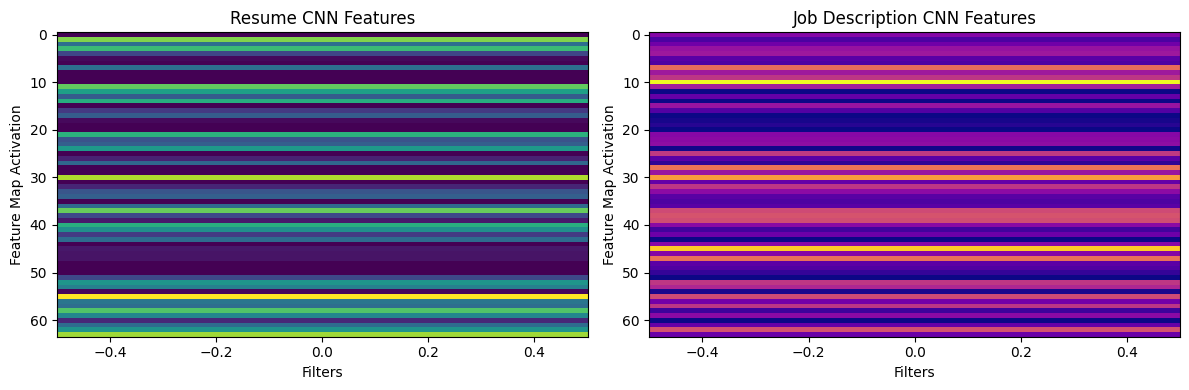

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------
# 0. Use GPU if available
# ------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ------------------------------
# 1. Load Dataset
# ------------------------------
df = pd.read_csv("/kaggle/input/resume-job/resume_job_dataset.csv")

# ------------------------------
# 2. Build Vocabulary
# ------------------------------
def build_vocab(df, min_freq=2):
    vocab = {"<UNK>": 0}
    word_counts = {}

    for text in df['resume_text'].tolist() + df['job_description_text'].tolist():
        words = str(text).lower().split()
        for word in words:
            word_counts[word] = word_counts.get(word, 0) + 1

    index = 1
    for word, count in word_counts.items():
        if count >= min_freq:
            vocab[word] = index
            index += 1

    return vocab

vocab = build_vocab(df)

# ------------------------------
# 3. Label Encoding
# ------------------------------
label_mapping = {"No Fit": 0, "Potential Fit": 1, "Good Fit": 2}
df["label"] = df["label"].map(label_mapping).astype(int)

# ------------------------------
# 4. Text to Tensor Conversion
# ------------------------------
def text_to_tensor(text, vocab, max_len=100):
    words = str(text).lower().split()
    indices = [vocab.get(word, vocab["<UNK>"]) for word in words]
    if len(indices) < max_len:
        indices += [0] * (max_len - len(indices))
    else:
        indices = indices[:max_len]
    return torch.tensor(indices)

# ------------------------------
# 5. Custom Dataset
# ------------------------------
class ResumeDataset(Dataset):
    def __init__(self, dataframe, vocab):
        self.data = dataframe
        self.vocab = vocab

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        resume_text = self.data.iloc[idx]["resume_text"]
        job_desc_text = self.data.iloc[idx]["job_description_text"]
        label = self.data.iloc[idx]["label"]

        resume_tensor = text_to_tensor(resume_text, self.vocab)
        job_desc_tensor = text_to_tensor(job_desc_text, self.vocab)
        label_tensor = torch.tensor(label)

        return resume_tensor, job_desc_tensor, label_tensor

# ------------------------------
# 6. Data Preparation
# ------------------------------
dataset = ResumeDataset(df, vocab)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

# ------------------------------
# 7. CNN Model Definition
# ------------------------------
class ResumeCNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, num_filters=64, filter_size=3, output_dim=3):
        super(ResumeCNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        self.conv1_resume = nn.Conv1d(embedding_dim, num_filters, kernel_size=filter_size)
        self.conv2_resume = nn.Conv1d(num_filters, num_filters, kernel_size=filter_size)

        self.conv1_job = nn.Conv1d(embedding_dim, num_filters, kernel_size=filter_size)
        self.conv2_job = nn.Conv1d(num_filters, num_filters, kernel_size=filter_size)

        self.fc1 = nn.Linear(num_filters * 2, 128)
        self.fc2 = nn.Linear(128, output_dim)

        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)

    def forward(self, resume, job_desc):
        resume_emb = self.embedding(resume).permute(0, 2, 1)
        job_emb = self.embedding(job_desc).permute(0, 2, 1)

        resume_feat = self.relu(self.conv1_resume(resume_emb))
        resume_feat = self.relu(self.conv2_resume(resume_feat))
        resume_feat = torch.max(resume_feat, dim=2)[0]

        job_feat = self.relu(self.conv1_job(job_emb))
        job_feat = self.relu(self.conv2_job(job_feat))
        job_feat = torch.max(job_feat, dim=2)[0]

        combined = torch.cat((resume_feat, job_feat), dim=1)

        hidden = self.relu(self.fc1(combined))
        output = self.softmax(self.fc2(hidden))

        return output, resume_feat, job_feat

# ------------------------------
# 8. Train the Model
# ------------------------------
model = ResumeCNN(len(vocab)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 15
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for resumes, job_descs, labels in train_loader:
        resumes = resumes.to(device)
        job_descs = job_descs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs, _, _ = model(resumes, job_descs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss/len(train_loader):.4f}")

# ------------------------------
# 9. Evaluate the Model
# ------------------------------
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for resumes, job_descs, labels in test_loader:
        resumes = resumes.to(device)
        job_descs = job_descs.to(device)
        labels = labels.to(device)

        outputs, _, _ = model(resumes, job_descs)
        predicted = torch.argmax(outputs, dim=1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

accuracy = correct / total
print(f"Test Accuracy: {accuracy:.4f}")

# ------------------------------
# 10. Visualize CNN Output
# ------------------------------
def visualize_cnn_output(model, resume_sample, job_desc_sample):
    model.eval()
    resume_sample = resume_sample.to(device)
    job_desc_sample = job_desc_sample.to(device)

    with torch.no_grad():
        _, resume_feat, job_feat = model(resume_sample.unsqueeze(0), job_desc_sample.unsqueeze(0))

    resume_feat = resume_feat.cpu().numpy()
    job_feat = job_feat.cpu().numpy()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].imshow(resume_feat.T, cmap="viridis", aspect="auto")
    axes[0].set_title("Resume CNN Features")
    axes[0].set_xlabel("Filters")
    axes[0].set_ylabel("Feature Map Activation")

    axes[1].imshow(job_feat.T, cmap="plasma", aspect="auto")
    axes[1].set_title("Job Description CNN Features")
    axes[1].set_xlabel("Filters")
    axes[1].set_ylabel("Feature Map Activation")

    plt.tight_layout()
    plt.show()

# Visualize sample
sample_resume, sample_job_desc, _ = dataset[0]
visualize_cnn_output(model, sample_resume, sample_job_desc)


# SKILL-6 : Apply augmentation , regularization, dropout to the above  data and implement classification and compare the result

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import pandas as pd
import matplotlib.pyplot as plt
import random

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# 1. Load Dataset
df = pd.read_csv("/kaggle/input/resume-job/resume_job_dataset.csv")

# 2. Build Vocabulary
def build_vocab(df, min_freq=2):
    vocab = {"<UNK>": 0}
    word_counts = {}
    for text in df['resume_text'].tolist() + df['job_description_text'].tolist():
        words = str(text).lower().split()
        for word in words:
            word_counts[word] = word_counts.get(word, 0) + 1
    index = 1
    for word, count in word_counts.items():
        if count >= min_freq:
            vocab[word] = index
            index += 1
    return vocab

vocab = build_vocab(df)

# 3. Label Encoding
label_mapping = {"No Fit": 0, "Potential Fit": 1, "Good Fit": 2}
df["label"] = df["label"].map(label_mapping).astype(int)

# 4. Text to Tensor + Augmentation
def augment_text(text, drop_prob=0.1):
    words = text.lower().split()
    augmented = [word for word in words if random.random() > drop_prob]
    return " ".join(augmented) if augmented else text

def text_to_tensor(text, vocab, max_len=100):
    words = str(text).lower().split()
    indices = [vocab.get(word, vocab["<UNK>"]) for word in words]
    if len(indices) < max_len:
        indices += [0] * (max_len - len(indices))
    else:
        indices = indices[:max_len]
    return torch.tensor(indices)

# 5. Dataset with Augmentation
class ResumeDataset(Dataset):
    def __init__(self, dataframe, vocab, augment=False):
        self.data = dataframe
        self.vocab = vocab
        self.augment = augment

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        resume_text = self.data.iloc[idx]["resume_text"]
        job_desc_text = self.data.iloc[idx]["job_description_text"]
        label = self.data.iloc[idx]["label"]

        if self.augment:
            resume_text = augment_text(resume_text)
            job_desc_text = augment_text(job_desc_text)

        resume_tensor = text_to_tensor(resume_text, self.vocab)
        job_desc_tensor = text_to_tensor(job_desc_text, self.vocab)
        return resume_tensor, job_desc_tensor, torch.tensor(label)

# 6. Train-Test Split
dataset = ResumeDataset(df, vocab, augment=True)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

# 7. CNN Model with Dropout
class ResumeCNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, num_filters=64, filter_size=3, output_dim=3, dropout=0.5):
        super(ResumeCNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        self.conv1_resume = nn.Conv1d(embedding_dim, num_filters, filter_size)
        self.conv2_resume = nn.Conv1d(num_filters, num_filters, filter_size)

        self.conv1_job = nn.Conv1d(embedding_dim, num_filters, filter_size)
        self.conv2_job = nn.Conv1d(num_filters, num_filters, filter_size)

        self.fc1 = nn.Linear(num_filters * 2, 128)
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(128, output_dim)

        self.relu = nn.ReLU()

    def forward(self, resume, job_desc):
        resume_emb = self.embedding(resume.to(device)).permute(0, 2, 1)
        job_emb = self.embedding(job_desc.to(device)).permute(0, 2, 1)

        resume_feat = self.relu(self.conv1_resume(resume_emb))
        resume_feat = self.relu(self.conv2_resume(resume_feat))
        resume_feat = torch.max(resume_feat, dim=2)[0]

        job_feat = self.relu(self.conv1_job(job_emb))
        job_feat = self.relu(self.conv2_job(job_feat))
        job_feat = torch.max(job_feat, dim=2)[0]

        combined = torch.cat((resume_feat, job_feat), dim=1)
        x = self.dropout(self.relu(self.fc1(combined)))
        return self.fc2(x)

# 8. Training & Evaluation
def train_and_evaluate(apply_regularization=False):
    model = ResumeCNN(len(vocab)).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4 if apply_regularization else 0.0)

    for epoch in range(20):
        model.train()
        total_loss = 0
        for resumes, job_descs, labels in train_loader:
            resumes, job_descs, labels = resumes.to(device), job_descs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(resumes, job_descs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1} Loss: {total_loss/len(train_loader):.4f}")

    # Test Accuracy
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for resumes, job_descs, labels in test_loader:
            resumes, job_descs, labels = resumes.to(device), job_descs.to(device), labels.to(device)
            outputs = model(resumes, job_descs)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total

# 9. Compare Results
acc_regularized = train_and_evaluate(apply_regularization=True)
print(f"Test Accuracy with Augmentation + Dropout + Weight Decay: {acc_regularized:.4f}")


Using device: cuda
Epoch 1 Loss: 1.0212
Epoch 2 Loss: 0.8768
Epoch 3 Loss: 0.8185
Epoch 4 Loss: 0.7779
Epoch 5 Loss: 0.7623
Epoch 6 Loss: 0.7329
Epoch 7 Loss: 0.7132
Epoch 8 Loss: 0.7102
Epoch 9 Loss: 0.6875
Epoch 10 Loss: 0.6723
Epoch 11 Loss: 0.6518
Epoch 12 Loss: 0.6380
Epoch 13 Loss: 0.6164
Epoch 14 Loss: 0.5788
Epoch 15 Loss: 0.5730
Epoch 16 Loss: 0.5431
Epoch 17 Loss: 0.5240
Epoch 18 Loss: 0.5029
Epoch 19 Loss: 0.4928
Epoch 20 Loss: 0.4818
Test Accuracy with Augmentation + Dropout + Weight Decay: 0.7742


# SKILL-7 : Implement a  VGG and alexnet models to classify project data by building 3 ‘blocks’ of 2 convolutional layers

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import pandas as pd
import matplotlib.pyplot as plt
import random

# 1. Load Dataset
df = pd.read_csv("/kaggle/input/resume-job/resume_job_dataset.csv")

# 2. Build Vocabulary
def build_vocab(df, min_freq=2):
    vocab = {"<UNK>": 0}
    word_counts = {}
    for text in df['resume_text'].tolist() + df['job_description_text'].tolist():
        words = str(text).lower().split()
        for word in words:
            word_counts[word] = word_counts.get(word, 0) + 1
    index = 1
    for word, count in word_counts.items():
        if count >= min_freq:
            vocab[word] = index
            index += 1
    return vocab

vocab = build_vocab(df)

# 3. Label Encoding
label_mapping = {"No Fit": 0, "Potential Fit": 1, "Good Fit": 2}
df["label"] = df["label"].map(label_mapping).astype(int)

# 4. Text to Tensor + Augmentation
def augment_text(text, drop_prob=0.1):
    words = text.lower().split()
    augmented = [word for word in words if random.random() > drop_prob]
    return " ".join(augmented) if augmented else text

def text_to_tensor(text, vocab, max_len=100):
    words = str(text).lower().split()
    indices = [vocab.get(word, vocab["<UNK>"]) for word in words]
    if len(indices) < max_len:
        indices += [0] * (max_len - len(indices))
    else:
        indices = indices[:max_len]
    return torch.tensor(indices)

# 5. Dataset with Augmentation
class ResumeDataset(Dataset):
    def __init__(self, dataframe, vocab, augment=False):
        self.data = dataframe
        self.vocab = vocab
        self.augment = augment

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        resume_text = self.data.iloc[idx]["resume_text"]
        job_desc_text = self.data.iloc[idx]["job_description_text"]
        label = self.data.iloc[idx]["label"]

        if self.augment:
            resume_text = augment_text(resume_text)
            job_desc_text = augment_text(job_desc_text)

        resume_tensor = text_to_tensor(resume_text, self.vocab)
        job_desc_tensor = text_to_tensor(job_desc_text, self.vocab)
        return resume_tensor, job_desc_tensor, torch.tensor(label)

# 6. Data Loaders
dataset = ResumeDataset(df, vocab, augment=True)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

# 7. Complete VGG16 for 1D Text
class VGG16Text(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, num_classes=3, dropout=0.5):
        super(VGG16Text, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        def vgg_block(in_channels):
            return nn.Sequential(
                nn.Conv1d(in_channels, 64, kernel_size=3, padding=1), nn.ReLU(),
                nn.Conv1d(64, 64, kernel_size=3, padding=1), nn.ReLU(),
                nn.MaxPool1d(kernel_size=2),

                nn.Conv1d(64, 128, kernel_size=3, padding=1), nn.ReLU(),
                nn.Conv1d(128, 128, kernel_size=3, padding=1), nn.ReLU(),
                nn.MaxPool1d(kernel_size=2),

                nn.Conv1d(128, 256, kernel_size=3, padding=1), nn.ReLU(),
                nn.Conv1d(256, 256, kernel_size=3, padding=1), nn.ReLU(),
                nn.Conv1d(256, 256, kernel_size=3, padding=1), nn.ReLU(),
                nn.MaxPool1d(kernel_size=2),

                nn.Conv1d(256, 512, kernel_size=3, padding=1), nn.ReLU(),
                nn.Conv1d(512, 512, kernel_size=3, padding=1), nn.ReLU(),
                nn.Conv1d(512, 512, kernel_size=3, padding=1), nn.ReLU(),
                nn.MaxPool1d(kernel_size=2),

                nn.Conv1d(512, 512, kernel_size=3, padding=1), nn.ReLU(),
                nn.Conv1d(512, 512, kernel_size=3, padding=1), nn.ReLU(),
                nn.Conv1d(512, 512, kernel_size=3, padding=1), nn.ReLU(),
                nn.AdaptiveMaxPool1d(1)
            )

        self.block_resume = vgg_block(embedding_dim)
        self.block_job = vgg_block(embedding_dim)

        self.fc = nn.Sequential(
            nn.Linear(512 * 2, 4096), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(4096, 4096), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(4096, num_classes)
        )

    def forward(self, resume, job_desc):
        resume = self.embedding(resume).permute(0, 2, 1)
        job_desc = self.embedding(job_desc).permute(0, 2, 1)

        resume_feat = self.block_resume(resume).squeeze(-1)
        job_feat = self.block_job(job_desc).squeeze(-1)

        combined = torch.cat((resume_feat, job_feat), dim=1)
        return self.fc(combined)

# 8. Complete AlexNet for 1D Text
class AlexNetText(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, num_classes=3, dropout=0.5):
        super(AlexNetText, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        def alex_block():
            return nn.Sequential(
                nn.Conv1d(embedding_dim, 96, kernel_size=11, stride=4, padding=5), nn.ReLU(),
                nn.MaxPool1d(kernel_size=3, stride=2),

                nn.Conv1d(96, 256, kernel_size=5, padding=2), nn.ReLU(),
                nn.MaxPool1d(kernel_size=3, stride=2),

                nn.Conv1d(256, 384, kernel_size=3, padding=1), nn.ReLU(),
                nn.Conv1d(384, 384, kernel_size=3, padding=1), nn.ReLU(),
                nn.Conv1d(384, 256, kernel_size=3, padding=1), nn.ReLU(),
                nn.AdaptiveMaxPool1d(1)
            )

        self.block_resume = alex_block()
        self.block_job = alex_block()

        self.classifier = nn.Sequential(
            nn.Linear(256 * 2, 4096), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(4096, 4096), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(4096, num_classes)
        )

    def forward(self, resume, job_desc):
        resume = self.embedding(resume).permute(0, 2, 1)
        job_desc = self.embedding(job_desc).permute(0, 2, 1)

        resume_feat = self.block_resume(resume).squeeze(-1)
        job_feat = self.block_job(job_desc).squeeze(-1)

        combined = torch.cat((resume_feat, job_feat), dim=1)
        return self.classifier(combined)

# 9. Train & Evaluate
def train_and_evaluate(model_class, device, vocab_size):
    model = model_class(vocab_size).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(15):  # Adjust epochs as needed
        model.train()
        total_loss = 0
        for resumes, job_descs, labels in train_loader:
            resumes, job_descs, labels = resumes.to(device), job_descs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(resumes, job_descs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"[{model_class.__name__}] Epoch {epoch+1} Loss: {total_loss/len(train_loader):.4f}")

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for resumes, job_descs, labels in test_loader:
            resumes, job_descs, labels = resumes.to(device), job_descs.to(device), labels.to(device)
            outputs = model(resumes, job_descs)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    acc = correct / total
    print(f"[{model_class.__name__}] Test Accuracy: {acc:.4f}")
    return acc

# 10. Run Both Models
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
acc_vgg = train_and_evaluate(VGG16Text, device, len(vocab))
acc_alex = train_and_evaluate(AlexNetText, device, len(vocab))


[VGG16Text] Epoch 1 Loss: 1.0461
[VGG16Text] Epoch 2 Loss: 1.0407
[VGG16Text] Epoch 3 Loss: 1.0403
[VGG16Text] Epoch 4 Loss: 1.0407
[VGG16Text] Epoch 5 Loss: 1.0405
[VGG16Text] Epoch 6 Loss: 1.0401
[VGG16Text] Epoch 7 Loss: 1.0406
[VGG16Text] Epoch 8 Loss: 1.0399
[VGG16Text] Epoch 9 Loss: 1.0407
[VGG16Text] Epoch 10 Loss: 1.0413
[VGG16Text] Epoch 11 Loss: 1.0396
[VGG16Text] Epoch 12 Loss: 1.0386
[VGG16Text] Epoch 13 Loss: 1.0388
[VGG16Text] Epoch 14 Loss: 1.0375
[VGG16Text] Epoch 15 Loss: 1.0394
[VGG16Text] Test Accuracy: 0.5028
[AlexNetText] Epoch 1 Loss: 1.0477
[AlexNetText] Epoch 2 Loss: 0.9595
[AlexNetText] Epoch 3 Loss: 0.8838
[AlexNetText] Epoch 4 Loss: 0.8490
[AlexNetText] Epoch 5 Loss: 0.8418
[AlexNetText] Epoch 6 Loss: 0.8270
[AlexNetText] Epoch 7 Loss: 0.8147
[AlexNetText] Epoch 8 Loss: 0.8213
[AlexNetText] Epoch 9 Loss: 0.8161
[AlexNetText] Epoch 10 Loss: 0.8041
[AlexNetText] Epoch 11 Loss: 0.7995
[AlexNetText] Epoch 12 Loss: 0.7922
[AlexNetText] Epoch 13 Loss: 0.7955
[AlexN

# SKILL-8 : Create a Recurrent neural network using pytorch   to classify or to generate sequences with  project data

In [18]:
# RNN-based Resume Screening Model using PyTorch

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import pandas as pd

# 1. Load Dataset
df = pd.read_csv("/kaggle/input/resume-job/resume_job_dataset.csv")

# 2. Vocabulary
def build_vocab(df, min_freq=2):
    vocab = {"<UNK>": 0}
    word_counts = {}
    for text in df['resume_text'].tolist() + df['job_description_text'].tolist():
        words = str(text).lower().split()
        for word in words:
            word_counts[word] = word_counts.get(word, 0) + 1
    index = 1
    for word, count in word_counts.items():
        if count >= min_freq:
            vocab[word] = index
            index += 1
    return vocab

vocab = build_vocab(df)

# 3. Label Encoding
label_mapping = {"No Fit": 0, "Potential Fit": 1, "Good Fit": 2}
df["label"] = df["label"].map(label_mapping).astype(int)

# 4. Text to Tensor
def text_to_tensor(text, vocab, max_len=100):
    words = str(text).lower().split()
    indices = [vocab.get(word, vocab["<UNK>"]) for word in words]
    if len(indices) < max_len:
        indices += [0] * (max_len - len(indices))
    else:
        indices = indices[:max_len]
    return torch.tensor(indices)

# 5. Dataset
class ResumeDataset(Dataset):
    def __init__(self, dataframe, vocab):
        self.data = dataframe
        self.vocab = vocab

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        resume = self.data.iloc[idx]["resume_text"]
        job_desc = self.data.iloc[idx]["job_description_text"]
        label = self.data.iloc[idx]["label"]

        resume_tensor = text_to_tensor(resume, self.vocab)
        job_desc_tensor = text_to_tensor(job_desc, self.vocab)
        return resume_tensor, job_desc_tensor, torch.tensor(label)

# 6. Split Dataset and Create DataLoaders
dataset = ResumeDataset(df, vocab)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

# 7. RNN Model
class ResumeRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, num_classes=3):
        super(ResumeRNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)

        self.rnn_resume = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        self.rnn_job = nn.RNN(embed_dim, hidden_dim, batch_first=True)

        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, resume, job_desc):
        resume_embed = self.embedding(resume)
        job_embed = self.embedding(job_desc)

        _, resume_hidden = self.rnn_resume(resume_embed)  # [1, B, H]
        _, job_hidden = self.rnn_job(job_embed)           # [1, B, H]

        combined = torch.cat((resume_hidden.squeeze(0), job_hidden.squeeze(0)), dim=1)
        output = self.fc(combined)
        return output

# 8. Train & Evaluate RNN
def train_and_evaluate_rnn(model_class, device, vocab_size):
    model = model_class(vocab_size).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(15):
        model.train()
        total_loss = 0
        correct_train, total_train = 0, 0

        for resumes, job_descs, labels in train_loader:
            resumes, job_descs, labels = resumes.to(device), job_descs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(resumes, job_descs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct_train += (preds == labels).sum().item()
            total_train += labels.size(0)

        train_acc = correct_train / total_train
        print(f"[RNN] Epoch {epoch+1} | Loss: {total_loss/len(train_loader):.4f} | Train Accuracy: {train_acc:.4f}")

    # Evaluation
    model.eval()
    correct_test, total_test = 0, 0
    with torch.no_grad():
        for resumes, job_descs, labels in test_loader:
            resumes, job_descs, labels = resumes.to(device), job_descs.to(device), labels.to(device)
            outputs = model(resumes, job_descs)
            preds = torch.argmax(outputs, dim=1)
            correct_test += (preds == labels).sum().item()
            total_test += labels.size(0)

    test_acc = correct_test / total_test
    print(f"[RNN] Final Test Accuracy: {test_acc:.4f}")

# 9. Run RNN Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_and_evaluate_rnn(ResumeRNN, device, len(vocab))


[RNN] Epoch 1 | Loss: 0.9200 | Train Accuracy: 0.5419
[RNN] Epoch 2 | Loss: 0.7761 | Train Accuracy: 0.6310
[RNN] Epoch 3 | Loss: 0.7313 | Train Accuracy: 0.6542
[RNN] Epoch 4 | Loss: 0.7028 | Train Accuracy: 0.6755
[RNN] Epoch 5 | Loss: 0.6842 | Train Accuracy: 0.6877
[RNN] Epoch 6 | Loss: 0.6626 | Train Accuracy: 0.7061
[RNN] Epoch 7 | Loss: 0.6540 | Train Accuracy: 0.7073
[RNN] Epoch 8 | Loss: 0.6416 | Train Accuracy: 0.7087
[RNN] Epoch 9 | Loss: 0.6363 | Train Accuracy: 0.7190
[RNN] Epoch 10 | Loss: 0.6294 | Train Accuracy: 0.7252
[RNN] Epoch 11 | Loss: 0.6228 | Train Accuracy: 0.7302
[RNN] Epoch 12 | Loss: 0.6176 | Train Accuracy: 0.7328
[RNN] Epoch 13 | Loss: 0.6126 | Train Accuracy: 0.7332
[RNN] Epoch 14 | Loss: 0.6068 | Train Accuracy: 0.7322
[RNN] Epoch 15 | Loss: 0.6067 | Train Accuracy: 0.7378
[RNN] Final Test Accuracy: 0.6429


# SKILL-9 : Generate  LSTM Model for classification and to identify patterns from the    project data set

In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import pandas as pd

# 1. Load Dataset
df = pd.read_csv("/kaggle/input/resume-job/resume_job_dataset.csv")

# 2. Vocabulary
def build_vocab(df, min_freq=2):
    vocab = {"<UNK>": 0}
    word_counts = {}
    for text in df['resume_text'].tolist() + df['job_description_text'].tolist():
        words = str(text).lower().split()
        for word in words:
            word_counts[word] = word_counts.get(word, 0) + 1
    index = 1
    for word, count in word_counts.items():
        if count >= min_freq:
            vocab[word] = index
            index += 1
    return vocab

vocab = build_vocab(df)

# 3. Label Encoding
label_mapping = {"No Fit": 0, "Potential Fit": 1, "Good Fit": 2}
df["label"] = df["label"].map(label_mapping).astype(int)

# 4. Text to Tensor
def text_to_tensor(text, vocab, max_len=100):
    words = str(text).lower().split()
    indices = [vocab.get(word, vocab["<UNK>"]) for word in words]
    if len(indices) < max_len:
        indices += [0] * (max_len - len(indices))
    else:
        indices = indices[:max_len]
    return torch.tensor(indices)

# 5. Dataset
class ResumeDataset(Dataset):
    def __init__(self, dataframe, vocab):
        self.data = dataframe
        self.vocab = vocab

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        resume = self.data.iloc[idx]["resume_text"]
        job_desc = self.data.iloc[idx]["job_description_text"]
        label = self.data.iloc[idx]["label"]

        resume_tensor = text_to_tensor(resume, self.vocab)
        job_desc_tensor = text_to_tensor(job_desc, self.vocab)
        return resume_tensor, job_desc_tensor, torch.tensor(label)

dataset = ResumeDataset(df, vocab)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

# 6. LSTM Model
class ResumeLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, num_classes=3, num_layers=1):
        super(ResumeLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)

        self.lstm_resume = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.lstm_job = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers, batch_first=True)

        self.fc1 = nn.Linear(hidden_dim * 2, 128)
        self.fc2 = nn.Linear(128, num_classes)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)

    def forward(self, resume, job_desc):
        resume_embed = self.embedding(resume)
        job_embed = self.embedding(job_desc)

        _, (resume_hidden, _) = self.lstm_resume(resume_embed)
        _, (job_hidden, _) = self.lstm_job(job_embed)

        combined = torch.cat((resume_hidden[-1], job_hidden[-1]), dim=1)
        x = self.relu(self.fc1(combined))
        x = self.dropout(x)
        return self.fc2(x)

# 7. Training & Evaluation
def train_and_evaluate_lstm(model_class, device, vocab_size):
    model = model_class(vocab_size).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(20):
        model.train()
        total_loss = 0
        correct_train, total_train = 0, 0

        for resumes, job_descs, labels in train_loader:
            resumes, job_descs, labels = resumes.to(device), job_descs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(resumes, job_descs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct_train += (preds == labels).sum().item()
            total_train += labels.size(0)

        train_acc = correct_train / total_train
        print(f"[LSTM] Epoch {epoch+1} | Loss: {total_loss/len(train_loader):.4f} | Train Accuracy: {train_acc:.4f}")

    model.eval()
    correct_test, total_test = 0, 0
    with torch.no_grad():
        for resumes, job_descs, labels in test_loader:
            resumes, job_descs, labels = resumes.to(device), job_descs.to(device), labels.to(device)
            outputs = model(resumes, job_descs)
            preds = torch.argmax(outputs, dim=1)
            correct_test += (preds == labels).sum().item()
            total_test += labels.size(0)

    test_acc = correct_test / total_test
    print(f"[LSTM] Final Test Accuracy: {test_acc:.4f}")

# 8. Run
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_and_evaluate_lstm(ResumeLSTM, device, len(vocab))


[LSTM] Epoch 1 | Loss: 0.9385 | Train Accuracy: 0.5383
[LSTM] Epoch 2 | Loss: 0.7663 | Train Accuracy: 0.6346
[LSTM] Epoch 3 | Loss: 0.6859 | Train Accuracy: 0.6743
[LSTM] Epoch 4 | Loss: 0.6269 | Train Accuracy: 0.6993
[LSTM] Epoch 5 | Loss: 0.5600 | Train Accuracy: 0.7396
[LSTM] Epoch 6 | Loss: 0.5065 | Train Accuracy: 0.7712
[LSTM] Epoch 7 | Loss: 0.4302 | Train Accuracy: 0.8175
[LSTM] Epoch 8 | Loss: 0.3771 | Train Accuracy: 0.8405
[LSTM] Epoch 9 | Loss: 0.3208 | Train Accuracy: 0.8652
[LSTM] Epoch 10 | Loss: 0.2957 | Train Accuracy: 0.8796
[LSTM] Epoch 11 | Loss: 0.2566 | Train Accuracy: 0.8932
[LSTM] Epoch 12 | Loss: 0.2392 | Train Accuracy: 0.9046
[LSTM] Epoch 13 | Loss: 0.2101 | Train Accuracy: 0.9195
[LSTM] Epoch 14 | Loss: 0.1932 | Train Accuracy: 0.9245
[LSTM] Epoch 15 | Loss: 0.1742 | Train Accuracy: 0.9297
[LSTM] Epoch 16 | Loss: 0.1644 | Train Accuracy: 0.9347
[LSTM] Epoch 17 | Loss: 0.1485 | Train Accuracy: 0.9425
[LSTM] Epoch 18 | Loss: 0.1362 | Train Accuracy: 0.9483
[

# SKILL-10 : Classify project data using any transfer learning models like ResNET and  MobileNet


In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import pandas as pd
import numpy as np

# 1. Load Dataset
df = pd.read_csv("/kaggle/input/resume-job/resume_job_dataset.csv")

# 2. Label Encoding
label_mapping = {"No Fit": 0, "Potential Fit": 1, "Good Fit": 2}
df["label"] = df["label"].map(label_mapping).astype(int)

# 3. Dummy Image Generator (for text-based data)
def text_to_image(text, image_size=(224, 224)):
    np.random.seed(abs(hash(text)) % (10 ** 8))
    data = np.random.rand(*image_size, 3) * 255
    return Image.fromarray(data.astype('uint8')).convert('RGB')

# 4. Dataset Class
class ResumeImageDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.data = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        resume_text = self.data.iloc[idx]['resume_text']
        job_text = self.data.iloc[idx]['job_description_text']
        label = self.data.iloc[idx]['label']
        combined_text = str(resume_text) + " " + str(job_text)
        image = text_to_image(combined_text)
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label)

# 5. Transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 6. Load Data
full_dataset = ResumeImageDataset(df, transform=transform)
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

# 7. Transfer Learning Models
def get_resnet(num_classes):
    model = models.resnet18(pretrained=True)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def get_mobilenet(num_classes):
    model = models.mobilenet_v2(pretrained=True)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    return model

# 8. Training Function
def train_transfer_model(model, device, train_loader, test_loader, epochs=5):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0005)

    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        acc = correct / total
        print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss:.4f} | Train Accuracy: {acc:.4f}")

    # Evaluation
    model.eval()
    correct_test, total_test = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            correct_test += (preds == labels).sum().item()
            total_test += labels.size(0)

    test_acc = correct_test / total_test
    print(f"Test Accuracy: {test_acc:.4f}")

# 9. Run
num_classes = 3
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Choose model
resnet_model = get_resnet(num_classes)
mobilenet_model = get_mobilenet(num_classes)

# Train one of them:
train_transfer_model(resnet_model, device, train_loader, test_loader, epochs=5)
# or
# train_transfer_model(mobilenet_model, device, train_loader, test_loader, epochs=5)


/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 217MB/s]
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed i

Epoch 1/5 | Loss: 169.1478 | Train Accuracy: 0.4748
Epoch 2/5 | Loss: 159.4305 | Train Accuracy: 0.5092
Epoch 3/5 | Loss: 147.4108 | Train Accuracy: 0.5491
Epoch 4/5 | Loss: 105.0615 | Train Accuracy: 0.7208
Epoch 5/5 | Loss: 47.7352 | Train Accuracy: 0.8824
Test Accuracy: 0.4876


# SKILL-11 : Apply   attention network and CNN model and classify the project  data

In [21]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from sklearn.model_selection import train_test_split

# ---------------------- Load and Prepare Data ----------------------
df = pd.read_csv("/kaggle/input/resume-job/resume_job_dataset.csv")

label_map = {"No Fit": 0, "Potential Fit": 1, "Good Fit": 2}
df["label"] = df["label"].map(label_map).astype(int)

# ---------------------- Tokenizer & Vocab ----------------------
def tokenize(text):
    return str(text).lower().split()

vocab = {"<PAD>": 0, "<UNK>": 1}
for col in ["resume_text", "job_description_text"]:
    for sentence in df[col]:
        for word in tokenize(sentence):
            if word not in vocab:
                vocab[word] = len(vocab)

# ---------------------- Text to Tensor ----------------------
def text_to_tensor(text, vocab, max_len=100):
    tokens = tokenize(text)
    ids = [vocab.get(token, vocab["<UNK>"]) for token in tokens]
    ids = ids[:max_len] + [0] * (max_len - len(ids))
    return torch.tensor(ids)

# ---------------------- Custom Dataset ----------------------
class ResumeJobDataset(Dataset):
    def __init__(self, df, vocab):
        self.resumes = df["resume_text"].tolist()
        self.jobs = df["job_description_text"].tolist()
        self.labels = df["label"].tolist()
        self.vocab = vocab

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        resume_tensor = text_to_tensor(self.resumes[idx], self.vocab)
        job_tensor = text_to_tensor(self.jobs[idx], self.vocab)
        label = torch.tensor(self.labels[idx])
        return resume_tensor, job_tensor, label

# ---------------------- CNN + Attention Model ----------------------
class CNNWithAttention(nn.Module):
    def __init__(self, vocab_size, embedding_dim=100, num_classes=3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        self.cnn = nn.Conv1d(embedding_dim, 128, kernel_size=3, padding=1)
        self.attn = nn.Linear(128, 1)

        self.fc = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, resume_x, job_x):
        r = self.embedding(resume_x).permute(0, 2, 1)  # (B, E, T)
        j = self.embedding(job_x).permute(0, 2, 1)

        r_feat = torch.relu(self.cnn(r)).permute(0, 2, 1)  # (B, T, C)
        j_feat = torch.relu(self.cnn(j)).permute(0, 2, 1)

        r_attn_weights = torch.softmax(self.attn(r_feat), dim=1)  # (B, T, 1)
        j_attn_weights = torch.softmax(self.attn(j_feat), dim=1)

        r_vector = torch.sum(r_feat * r_attn_weights, dim=1)
        j_vector = torch.sum(j_feat * j_attn_weights, dim=1)

        combined = torch.cat([r_vector, j_vector], dim=1)
        out = self.fc(combined)
        return out

# ---------------------- Prepare Dataloaders ----------------------
dataset = ResumeJobDataset(df, vocab)
train_data, test_data = train_test_split(dataset, test_size=0.2)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32)

# ---------------------- Train Model ----------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNNWithAttention(vocab_size=len(vocab)).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(20):
    model.train()
    total_loss = 0
    for resume, job, label in train_loader:
        resume, job, label = resume.to(device), job.to(device), label.to(device)

        optimizer.zero_grad()
        output = model(resume, job)
        loss = criterion(output, label)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

# ---------------------- Evaluate Model ----------------------
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for resume, job, label in test_loader:
        resume, job, label = resume.to(device), job.to(device), label.to(device)
        output = model(resume, job)
        predicted = torch.argmax(output, dim=1)
        correct += (predicted == label).sum().item()
        total += label.size(0)

print(f"Test Accuracy: {correct / total:.4f}")


Epoch 1, Loss: 0.9857
Epoch 2, Loss: 0.7845
Epoch 3, Loss: 0.7052
Epoch 4, Loss: 0.6559
Epoch 5, Loss: 0.6199
Epoch 6, Loss: 0.5823
Epoch 7, Loss: 0.5389
Epoch 8, Loss: 0.4946
Epoch 9, Loss: 0.4402
Epoch 10, Loss: 0.3915
Epoch 11, Loss: 0.3383
Epoch 12, Loss: 0.2990
Epoch 13, Loss: 0.2555
Epoch 14, Loss: 0.2247
Epoch 15, Loss: 0.2041
Epoch 16, Loss: 0.1844
Epoch 17, Loss: 0.1649
Epoch 18, Loss: 0.1600
Epoch 19, Loss: 0.1386
Epoch 20, Loss: 0.1225
Test Accuracy: 0.7902


# SKILL- 12 :  Apply Transformer and CNN model and classify the project  data 

In [22]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from sklearn.model_selection import train_test_split

# ---------------- Load Dataset ----------------
df = pd.read_csv("/kaggle/input/resume-job/resume_job_dataset.csv")

label_map = {"No Fit": 0, "Potential Fit": 1, "Good Fit": 2}
df["label"] = df["label"].map(label_map).astype(int)

# ---------------- Tokenization and Vocab ----------------
def tokenize(text):
    return str(text).lower().split()

vocab = {"<PAD>": 0, "<UNK>": 1}
for col in ["resume_text", "job_description_text"]:
    for sentence in df[col]:
        for word in tokenize(sentence):
            if word not in vocab:
                vocab[word] = len(vocab)

def text_to_tensor(text, vocab, max_len=100):
    tokens = tokenize(text)
    ids = [vocab.get(w, vocab["<UNK>"]) for w in tokens][:max_len]
    return torch.tensor(ids + [0]*(max_len - len(ids)))

# ---------------- Custom Dataset ----------------
class ResumeJobDataset(Dataset):
    def __init__(self, df, vocab):
        self.resume = df["resume_text"].tolist()
        self.job = df["job_description_text"].tolist()
        self.labels = df["label"].tolist()
        self.vocab = vocab

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        r = text_to_tensor(self.resume[idx], self.vocab)
        j = text_to_tensor(self.job[idx], self.vocab)
        label = torch.tensor(self.labels[idx])
        return r, j, label

# ---------------- Transformer + CNN Model ----------------
class CNNTransformerClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, num_classes=3, num_heads=4):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)

        self.cnn = nn.Conv1d(embed_dim, embed_dim, kernel_size=3, padding=1)

        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=num_heads, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)

        self.fc = nn.Sequential(
            nn.Linear(embed_dim * 2, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, resume, job):
        r_embed = self.embedding(resume)  # (B, T, E)
        j_embed = self.embedding(job)

        # CNN expects (B, E, T)
        r_feat = torch.relu(self.cnn(r_embed.permute(0, 2, 1))).permute(0, 2, 1)
        j_feat = torch.relu(self.cnn(j_embed.permute(0, 2, 1))).permute(0, 2, 1)

        r_encoded = self.transformer(r_feat)  # (B, T, E)
        j_encoded = self.transformer(j_feat)

        r_vector = r_encoded.mean(dim=1)
        j_vector = j_encoded.mean(dim=1)

        combined = torch.cat([r_vector, j_vector], dim=1)
        return self.fc(combined)

# ---------------- Training ----------------
dataset = ResumeJobDataset(df, vocab)
train_data, test_data = train_test_split(dataset, test_size=0.2, random_state=42)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNNTransformerClassifier(len(vocab)).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(20):
    model.train()
    total_loss = 0
    for r, j, label in train_loader:
        r, j, label = r.to(device), j.to(device), label.to(device)
        optimizer.zero_grad()
        out = model(r, j)
        loss = loss_fn(out, label)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}: Loss = {total_loss/len(train_loader):.4f}")

# ---------------- Evaluation ----------------
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for r, j, label in test_loader:
        r, j, label = r.to(device), j.to(device), label.to(device)
        out = model(r, j)
        preds = torch.argmax(out, dim=1)
        correct += (preds == label).sum().item()
        total += label.size(0)

print(f"Test Accuracy: {correct / total:.4f}")


Epoch 1: Loss = 1.0232
Epoch 2: Loss = 0.8566
Epoch 3: Loss = 0.7843
Epoch 4: Loss = 0.7563
Epoch 5: Loss = 0.7351
Epoch 6: Loss = 0.7215
Epoch 7: Loss = 0.7250
Epoch 8: Loss = 0.7113
Epoch 9: Loss = 0.7029
Epoch 10: Loss = 0.7289
Epoch 11: Loss = 0.7289
Epoch 12: Loss = 0.8207
Epoch 13: Loss = 0.8296
Epoch 14: Loss = 0.8503
Epoch 15: Loss = 0.8409
Epoch 16: Loss = 0.8194
Epoch 17: Loss = 0.8153
Epoch 18: Loss = 0.8600
Epoch 19: Loss = 0.8223
Epoch 20: Loss = 0.7753
Test Accuracy: 0.5364


# BERT and BiLSTM with Attention 

In [26]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertModel
import pandas as pd
from sklearn.model_selection import train_test_split

# ------------------- Load Dataset -------------------
df = pd.read_csv("/kaggle/input/resume-job/resume_job_dataset.csv")

label_map = {"No Fit": 0, "Potential Fit": 1, "Good Fit": 2}
df["label"] = df["label"].map(label_map).astype(int)

# ------------------- Constants -------------------
MAX_LEN = 128
BATCH_SIZE = 16

# ------------------- Tokenizer -------------------
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# ------------------- Dataset Class -------------------
class BERTBiLSTMDataset(Dataset):
    def __init__(self, df, tokenizer, max_len):
        self.resume = df["resume_text"].tolist()
        self.job = df["job_description_text"].tolist()
        self.labels = df["label"].tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        r_text = str(self.resume[idx])
        j_text = str(self.job[idx])
        label = torch.tensor(self.labels[idx])

        r = self.tokenizer(r_text, padding='max_length', truncation=True, max_length=self.max_len, return_tensors="pt")
        j = self.tokenizer(j_text, padding='max_length', truncation=True, max_length=self.max_len, return_tensors="pt")

        return {
            "r_input_ids": r["input_ids"].squeeze(0),
            "r_attention_mask": r["attention_mask"].squeeze(0),
            "j_input_ids": j["input_ids"].squeeze(0),
            "j_attention_mask": j["attention_mask"].squeeze(0),
            "label": label
        }

# ------------------- Attention Layer -------------------
class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, x):  # x: (batch, seq, hidden)
        weights = torch.softmax(self.attn(x), dim=1)  # (batch, seq, 1)
        output = (x * weights).sum(dim=1)  # (batch, hidden)
        return output

# ------------------- Model -------------------
class BERTBiLSTMAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.bert = BertModel.from_pretrained("bert-base-uncased")
        self.lstm = nn.LSTM(768, 256, batch_first=True, bidirectional=True)
        self.attn = Attention(512)
        self.fc = nn.Sequential(
            nn.Linear(512 * 2, 128),
            nn.ReLU(),
            nn.Linear(128, 3)
        )

    def encode(self, input_ids, attention_mask):
        with torch.no_grad():
            outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        x, _ = self.lstm(outputs.last_hidden_state)
        return self.attn(x)

    def forward(self, r_input_ids, r_mask, j_input_ids, j_mask):
        r_vec = self.encode(r_input_ids, r_mask)
        j_vec = self.encode(j_input_ids, j_mask)
        combined = torch.cat([r_vec, j_vec], dim=1)
        return self.fc(combined)

# ------------------- Prepare Data -------------------
dataset = BERTBiLSTMDataset(df, tokenizer, MAX_LEN)
train_data, test_data = train_test_split(dataset, test_size=0.2, random_state=42)
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE)

# ------------------- Train -------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = BERTBiLSTMAttention().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=2e-5)

for epoch in range(100):
    model.train()
    total_loss = 0
    for batch in train_loader:
        r_ids = batch['r_input_ids'].to(device)
        r_mask = batch['r_attention_mask'].to(device)
        j_ids = batch['j_input_ids'].to(device)
        j_mask = batch['j_attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(r_ids, r_mask, j_ids, j_mask)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss / len(train_loader):.4f}")

# ------------------- Evaluation -------------------
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for batch in test_loader:
        r_ids = batch['r_input_ids'].to(device)
        r_mask = batch['r_attention_mask'].to(device)
        j_ids = batch['j_input_ids'].to(device)
        j_mask = batch['j_attention_mask'].to(device)
        labels = batch['label'].to(device)

        outputs = model(r_ids, r_mask, j_ids, j_mask)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

print(f"Test Accuracy: {correct / total:.4f}")

Using device: cuda
Epoch 1, Loss: 1.0457
Epoch 2, Loss: 1.0293
Epoch 3, Loss: 0.9981
Epoch 4, Loss: 0.9141
Epoch 5, Loss: 0.8445
Epoch 6, Loss: 0.8187
Epoch 7, Loss: 0.7952
Epoch 8, Loss: 0.7834
Epoch 9, Loss: 0.7723
Epoch 10, Loss: 0.7566
Epoch 11, Loss: 0.7516
Epoch 12, Loss: 0.7407
Epoch 13, Loss: 0.7331
Epoch 14, Loss: 0.7312
Epoch 15, Loss: 0.7230
Epoch 16, Loss: 0.7162
Epoch 17, Loss: 0.7051
Epoch 18, Loss: 0.6997
Epoch 19, Loss: 0.6972
Epoch 20, Loss: 0.6840
Epoch 21, Loss: 0.6808
Epoch 22, Loss: 0.6767
Epoch 23, Loss: 0.6657
Epoch 24, Loss: 0.6615
Epoch 25, Loss: 0.6549
Epoch 26, Loss: 0.6501
Epoch 27, Loss: 0.6513
Epoch 28, Loss: 0.6394
Epoch 29, Loss: 0.6298
Epoch 30, Loss: 0.6292
Epoch 31, Loss: 0.6239
Epoch 32, Loss: 0.6188
Epoch 33, Loss: 0.6551
Epoch 34, Loss: 0.6089
Epoch 35, Loss: 0.5999
Epoch 36, Loss: 0.6015
Epoch 37, Loss: 0.5979
Epoch 38, Loss: 0.5898
Epoch 39, Loss: 0.5857
Epoch 40, Loss: 0.5773
Epoch 41, Loss: 0.5694
Epoch 42, Loss: 0.5717
Epoch 43, Loss: 0.5674
E

In [4]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertModel, AdamW, get_linear_schedule_with_warmup
import pandas as pd
from sklearn.model_selection import train_test_split

# ---------------- Load Dataset ----------------
df = pd.read_csv("/kaggle/input/resume-job/resume_job_dataset.csv")
label_map = {"No Fit": 0, "Potential Fit": 1, "Good Fit": 2}
df["label"] = df["label"].map(label_map).astype(int)

# ---------------- Tokenizer ----------------
MAX_LEN = 128
BATCH_SIZE = 16
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# ---------------- Dataset ----------------
class ResumeJobDataset(Dataset):
    def __init__(self, df, tokenizer, max_len):
        self.resume = df["resume_text"].tolist()
        self.job = df["job_description_text"].tolist()
        self.labels = df["label"].tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        r_text = str(self.resume[idx])
        j_text = str(self.job[idx])
        label = torch.tensor(self.labels[idx])

        r = self.tokenizer(r_text, padding='max_length', truncation=True, max_length=self.max_len, return_tensors="pt")
        j = self.tokenizer(j_text, padding='max_length', truncation=True, max_length=self.max_len, return_tensors="pt")

        return {
            "r_input_ids": r["input_ids"].squeeze(0),
            "r_attention_mask": r["attention_mask"].squeeze(0),
            "j_input_ids": j["input_ids"].squeeze(0),
            "j_attention_mask": j["attention_mask"].squeeze(0),
            "label": label
        }

# ---------------- Attention Layer ----------------
class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        weights = torch.softmax(self.attn(x), dim=1)
        return (x * weights).sum(dim=1)

# ---------------- Model ----------------
class BERTBiLSTMAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.bert = BertModel.from_pretrained("bert-base-uncased")
        self.lstm = nn.LSTM(768, 256, batch_first=True, bidirectional=True)
        self.attn = Attention(512)
        self.dropout = nn.Dropout(0.3)
        self.norm = nn.LayerNorm(512)
        self.fc = nn.Sequential(
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 3)
        )

    def encode(self, input_ids, attention_mask):
        with torch.no_grad():
            outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        x, _ = self.lstm(outputs.last_hidden_state)
        x = self.norm(x)
        return self.attn(self.dropout(x))

    def forward(self, r_input_ids, r_mask, j_input_ids, j_mask):
        r_vec = self.encode(r_input_ids, r_mask)
        j_vec = self.encode(j_input_ids, j_mask)
        combined = torch.cat([r_vec, j_vec], dim=1)
        return self.fc(combined)

# ---------------- Data Preparation ----------------
dataset = ResumeJobDataset(df, tokenizer, MAX_LEN)
train_data, test_data = train_test_split(dataset, test_size=0.2, random_state=42)
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE)

# ---------------- Training ----------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BERTBiLSTMAttention().to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = AdamW(model.parameters(), lr=2e-5)

total_steps = len(train_loader) * 15
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)

# ---------------- Fine-tuning strategy ----------------
# Freeze BERT for first 5 epochs
for param in model.bert.parameters():
    param.requires_grad = False

# ---------------- Training Loop ----------------
for epoch in range(15):
    model.train()
    total_loss = 0
    if epoch == 5:
        print("Unfreezing BERT for fine-tuning...")
        for param in model.bert.parameters():
            param.requires_grad = True

    for batch in train_loader:
        r_ids = batch['r_input_ids'].to(device)
        r_mask = batch['r_attention_mask'].to(device)
        j_ids = batch['j_input_ids'].to(device)
        j_mask = batch['j_attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(r_ids, r_mask, j_ids, j_mask)
        loss = loss_fn(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss / len(train_loader):.4f}")

# ---------------- Evaluation ----------------
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for batch in test_loader:
        r_ids = batch['r_input_ids'].to(device)
        r_mask = batch['r_attention_mask'].to(device)
        j_ids = batch['j_input_ids'].to(device)
        j_mask = batch['j_attention_mask'].to(device)
        labels = batch['label'].to(device)

        outputs = model(r_ids, r_mask, j_ids, j_mask)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

print(f"Final Test Accuracy: {correct / total:.4f}")


/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Epoch 1, Loss: 1.0324
Epoch 2, Loss: 0.9923
Epoch 3, Loss: 0.9543
Epoch 4, Loss: 0.9093
Epoch 5, Loss: 0.8694
Unfreezing BERT for fine-tuning...
Epoch 6, Loss: 0.8376
Epoch 7, Loss: 0.8132
Epoch 8, Loss: 0.7980
Epoch 9, Loss: 0.7848
Epoch 10, Loss: 0.7698
Epoch 11, Loss: 0.7645
Epoch 12, Loss: 0.7640
Epoch 13, Loss: 0.7568
Epoch 14, Loss: 0.7534
Epoch 15, Loss: 0.7504
Final Test Accuracy: 0.6061


In [1]:
!pip install torch torchvision transformers scikit-learn pandas

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertModel
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Load Dataset
df = pd.read_csv("/kaggle/input/resume-job/resume_job_dataset.csv")

# 2. Label Encoding
label_map = {"No Fit": 0, "Potential Fit": 1, "Good Fit": 2}
df["label"] = df["label"].map(label_map).astype(int)

# 3. Constants
MAX_LEN = 128
BATCH_SIZE = 16
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# 4. Tokenizer
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# 5. Dataset
class ResumeJobDataset(Dataset):
    def __init__(self, df, tokenizer, max_len):
        self.resume = df["resume_text"].tolist()
        self.job = df["job_description_text"].tolist()
        self.labels = df["label"].tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        resume = str(self.resume[idx])
        job = str(self.job[idx])
        label = torch.tensor(self.labels[idx])

        resume_tokens = self.tokenizer(resume, padding='max_length', truncation=True,
                                       max_length=self.max_len, return_tensors="pt")
        job_tokens = self.tokenizer(job, padding='max_length', truncation=True,
                                    max_length=self.max_len, return_tensors="pt")

        return {
            "r_input_ids": resume_tokens["input_ids"].squeeze(0),
            "r_attention_mask": resume_tokens["attention_mask"].squeeze(0),
            "j_input_ids": job_tokens["input_ids"].squeeze(0),
            "j_attention_mask": job_tokens["attention_mask"].squeeze(0),
            "label": label
        }

# 6. Attention Layer
class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, x):  # x: (batch, seq_len, hidden)
        scores = torch.softmax(self.attn(x), dim=1)  # (batch, seq_len, 1)
        output = (x * scores).sum(dim=1)  # (batch, hidden)
        return output

# 7. BERT + BiLSTM + Attention Model
class BERTBiLSTMAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.bert = BertModel.from_pretrained("bert-base-uncased")
        self.lstm = nn.LSTM(input_size=768, hidden_size=256, batch_first=True, bidirectional=True)
        self.attn = Attention(512)
        self.fc = nn.Sequential(
            nn.Linear(512 * 2, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 3)
        )

    def encode(self, input_ids, attention_mask):
        with torch.no_grad():
            outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        lstm_out, _ = self.lstm(outputs.last_hidden_state)  # (batch, seq, 512)
        return self.attn(lstm_out)  # (batch, 512)

    def forward(self, r_input_ids, r_mask, j_input_ids, j_mask):
        r_vec = self.encode(r_input_ids, r_mask)
        j_vec = self.encode(j_input_ids, j_mask)
        combined = torch.cat((r_vec, j_vec), dim=1)  # (batch, 1024)
        return self.fc(combined)

# 8. Data Loaders
dataset = ResumeJobDataset(df, tokenizer, MAX_LEN)
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
train_data = ResumeJobDataset(train_df, tokenizer, MAX_LEN)
test_data = ResumeJobDataset(test_df, tokenizer, MAX_LEN)
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE)

# 9. Training
model = BERTBiLSTMAttention().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(50):  # Try increasing to 20–30 for better results
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch in train_loader:
        r_ids = batch['r_input_ids'].to(device)
        r_mask = batch['r_attention_mask'].to(device)
        j_ids = batch['j_input_ids'].to(device)
        j_mask = batch['j_attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(r_ids, r_mask, j_ids, j_mask)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    print(f"Epoch {epoch+1} | Loss: {total_loss/len(train_loader):.4f} | Train Acc: {correct/total:.4f}")

# 10. Evaluation
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for batch in test_loader:
        r_ids = batch['r_input_ids'].to(device)
        r_mask = batch['r_attention_mask'].to(device)
        j_ids = batch['j_input_ids'].to(device)
        j_mask = batch['j_attention_mask'].to(device)
        labels = batch['label'].to(device)

        outputs = model(r_ids, r_mask, j_ids, j_mask)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

print(f"Final Test Accuracy: {correct / total:.4f}")


Using device: cuda


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Epoch 1 | Loss: 1.0103 | Train Acc: 0.5026
Epoch 2 | Loss: 0.8577 | Train Acc: 0.5565
Epoch 3 | Loss: 0.7632 | Train Acc: 0.6212
Epoch 4 | Loss: 0.7022 | Train Acc: 0.6595
Epoch 5 | Loss: 0.6606 | Train Acc: 0.6859
Epoch 6 | Loss: 0.6274 | Train Acc: 0.7063
Epoch 7 | Loss: 0.6010 | Train Acc: 0.7218
Epoch 8 | Loss: 0.5684 | Train Acc: 0.7440
Epoch 9 | Loss: 0.5373 | Train Acc: 0.7674
Epoch 10 | Loss: 0.5088 | Train Acc: 0.7817
Epoch 11 | Loss: 0.4797 | Train Acc: 0.7943
Epoch 12 | Loss: 0.4448 | Train Acc: 0.8077
Epoch 13 | Loss: 0.4032 | Train Acc: 0.8271
Epoch 14 | Loss: 0.3796 | Train Acc: 0.8357
Epoch 15 | Loss: 0.3628 | Train Acc: 0.8488
Epoch 16 | Loss: 0.3395 | Train Acc: 0.8552
Epoch 17 | Loss: 0.3287 | Train Acc: 0.8638
Epoch 18 | Loss: 0.3128 | Train Acc: 0.8706
Epoch 19 | Loss: 0.2826 | Train Acc: 0.8850
Epoch 20 | Loss: 0.2633 | Train Acc: 0.8904
Epoch 21 | Loss: 0.2475 | Train Acc: 0.8992
Epoch 22 | Loss: 0.2437 | Train Acc: 0.8988
Epoch 23 | Loss: 0.2369 | Train Acc: 0.90

In [4]:
import os

# Folder to save artifacts
SAVE_DIR = "./artifacts"
os.makedirs(SAVE_DIR, exist_ok=True)

# 1. Save model weights
torch.save(model.state_dict(), os.path.join(SAVE_DIR, "model.pth"))

# 2. Save tokenizer
tokenizer.save_pretrained(SAVE_DIR)

# 3. Save label map and constants
import json
artifacts = {
    "label_map": label_map,
    "MAX_LEN": MAX_LEN
}
with open(os.path.join(SAVE_DIR, "config.json"), "w") as f:
    json.dump(artifacts, f)

print("✅ Model, tokenizer, and config saved in", SAVE_DIR)


✅ Model, tokenizer, and config saved in ./artifacts


In [5]:
import shutil

# Path where artifacts were saved
SAVE_DIR = "/kaggle/working/artifacts"

# Create a zip file of the entire directory
shutil.make_archive("/kaggle/working/artifacts", 'zip', SAVE_DIR)

print("✅ Artifacts zipped at /kaggle/working/artifacts.zip")


✅ Artifacts zipped at /kaggle/working/artifacts.zip


In [22]:
import torch
from transformers import BertTokenizer
import json

# Load artifacts
SAVE_DIR = "./artifacts"
tokenizer = BertTokenizer.from_pretrained(SAVE_DIR)

with open(os.path.join(SAVE_DIR, "config.json")) as f:
    artifacts = json.load(f)

label_map = artifacts["label_map"]
MAX_LEN = artifacts["MAX_LEN"]

# Recreate model architecture
model = BERTBiLSTMAttention()
model.load_state_dict(torch.load(os.path.join(SAVE_DIR, "model.pth"), map_location=device))
model.to(device)
model.eval()
print("✅ Model and tokenizer loaded successfully")


<ipython-input-22-f925e4e08ee0>:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(os.path.join(SAVE_DIR, "model.pth"), map_location=device))

✅ Model and tokenizer loaded successfully


In [23]:
def predict_resume_fit(resume_text, job_text):
    # Tokenize inputs
    resume_tokens = tokenizer(resume_text, padding='max_length', truncation=True,
                              max_length=MAX_LEN, return_tensors="pt")
    job_tokens = tokenizer(job_text, padding='max_length', truncation=True,
                           max_length=MAX_LEN, return_tensors="pt")

    # Move to device
    r_ids = resume_tokens["input_ids"].to(device)
    r_mask = resume_tokens["attention_mask"].to(device)
    j_ids = job_tokens["input_ids"].to(device)
    j_mask = job_tokens["attention_mask"].to(device)

    # Run inference
    with torch.no_grad():
        outputs = model(r_ids, r_mask, j_ids, j_mask)
        pred = torch.argmax(outputs, dim=1).item()

    # Reverse label map
    inv_label_map = {v: k for k, v in label_map.items()}
    return inv_label_map[pred]


In [24]:
resume = "Experienced Python developer with ML background"
job = "Looking for a python developer with ML."

result = predict_resume_fit(resume, job)
print("Prediction:", result)  # → No Fit / Potential Fit / Good Fit


Prediction: No Fit


In [26]:
data_set = pd.read_csv("/kaggle/input/resume-job/resume_job_dataset.csv")

data_set.columns

Index(['resume_text', 'job_description_text', 'label'], dtype='object')

In [33]:
data_set.shape

(6241, 3)

In [35]:
res = data_set['resume_text'][6000]
jd = data_set['job_description_text'][6000]
lab = data_set['label'][6000]

print(res)
print(jd)
print(lab)

SummaryMotivated accounting professional focused on maintaining accurate, compliant records and controls. Detail-oriented, trustworthy, and able to work in a team.
SkillsFinancial statement analysisGeneral ledger accountingAccount reconciliationAccount reconciliation expert
Education and TrainingCalifornia State University - Los AngelesLos Angeles,CAExpected in––Bachelor of Science:Finance-GPA:
ExperiencePetco-Staff AccountantVancouver,WA,01/2012-06/2017Investigated and resolved discrepancies in monthly bank accounts.Processed payroll, electronic deposits and employee pay adjustments.Monitored and tracked expenses to keep business on track with financial targets.Managed financial operatons, month-end reporting, financial schedules and reconciliations.Assessed accuracy and completeness of company financial records.Created monthly financial statements using Excel.Reviewed and reconciled discrepancies in accounts and financial documentation.Actua Corporation-Junior Staff AccountantTampa,F

In [36]:
result = predict_resume_fit(res, jd)
print("Prediction:", result)

Prediction: Good Fit
